In [ ]:
from utils import load_data, split_data, preprocess
from utils import preprocess_v1, preprocess_v2, preprocess_v3, preprocess_v4
from utils import compare_errors, plot_error_matrix, print_error_examples
from utils import max_features, prepare_plot_data, analyze_common_cases

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

In [56]:
df, X, y = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print("Liczba przykładów:")
print(f"  treningowych   {len(y_train):,}")
print(f"  walidacyjnych  {len(y_val):,}")
print(f"  testowych      {len(y_test):,}")

Liczba przykładów:
  treningowych   36,876
  walidacyjnych  7,902
  testowych      7,903


In [13]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("log_reg", LogisticRegression(max_iter=1_000))
])

### Elementy preprocessingu
...

### Eksperyment 1.1
- usunięcie stopwords 
- lematyzacja `WordNetLemmatizer`

In [14]:
X_train_v1 = X_train.apply(preprocess_v1)
X_val_v1 = X_val.apply(preprocess_v1)
X_test_v1 = X_test.apply(preprocess_v1)

In [15]:
baseline.fit(X_train_v1, y_train)
y_val_pred_v1 = baseline.predict(X_val_v1)
f1_macro_v1 = f1_score(y_val, y_val_pred_v1, average='macro')

print(classification_report(y_val, y_val_pred_v1))
print(f"F1 macro: {f1_macro_v1:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.81      0.69      0.74       576
             Bipolar       0.89      0.59      0.71       416
          Depression       0.65      0.74      0.69      2311
              Normal       0.83      0.94      0.88      2451
Personality disorder       0.90      0.38      0.53       162
              Stress       0.67      0.36      0.46       388
            Suicidal       0.67      0.62      0.64      1598

            accuracy                           0.74      7902
           macro avg       0.77      0.61      0.67      7902
        weighted avg       0.74      0.74      0.73      7902

F1 macro: 0.67


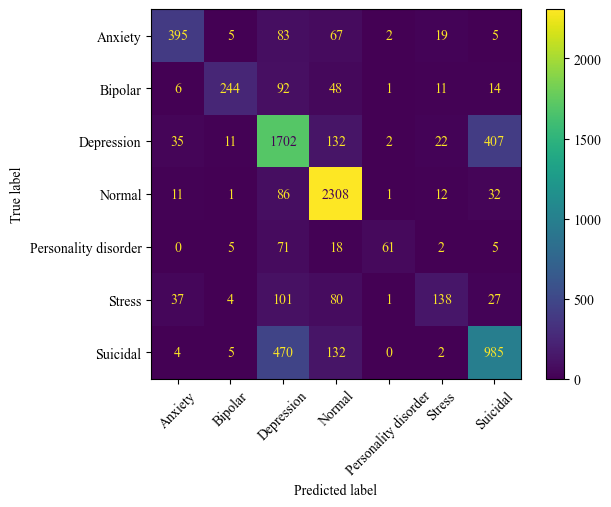

In [16]:
cm_v1 = confusion_matrix(y_val, y_val_pred_v1)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_v1,
    xticks_rotation=45)

### Eksperyment 1.2
- usunięcie stopwords
- tylko alfanumeryczne tokeny
- lematyzacja `WordNetLemmatizer`

In [17]:
X_train_v2 = X_train.apply(preprocess_v2)
X_val_v2 = X_val.apply(preprocess_v2)
X_test_v2 = X_test.apply(preprocess_v2)

In [18]:
baseline.fit(X_train_v2, y_train)
y_val_pred_v2 = baseline.predict(X_val_v2)
f1_macro_v2 = f1_score(y_val, y_val_pred_v2, average='macro')

print(classification_report(y_val, y_val_pred_v2))
print(f"F1 macro: {f1_macro_v2:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.81      0.68      0.74       576
             Bipolar       0.88      0.58      0.70       416
          Depression       0.65      0.73      0.69      2311
              Normal       0.83      0.94      0.88      2451
Personality disorder       0.91      0.36      0.52       162
              Stress       0.70      0.36      0.47       388
            Suicidal       0.65      0.60      0.63      1598

            accuracy                           0.73      7902
           macro avg       0.78      0.61      0.66      7902
        weighted avg       0.74      0.73      0.73      7902

F1 macro: 0.66


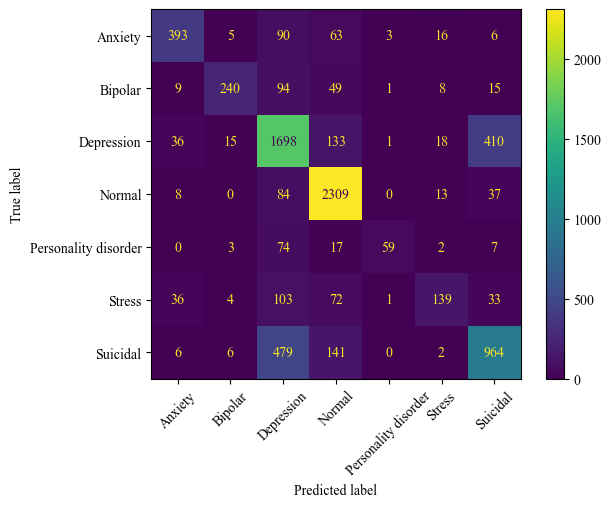

In [19]:
cm_v2 = confusion_matrix(y_val, y_val_pred_v2)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_v2,
    xticks_rotation=45)

### Eksperyment 1.3
- usunięcie stopwords 
- lematyzacja uwzględniająca części mowy

In [20]:
X_train_v3 = X_train.apply(preprocess_v3)
X_val_v3 = X_val.apply(preprocess_v3)
X_test_v3 = X_test.apply(preprocess_v3)

In [21]:
baseline.fit(X_train_v3, y_train)
y_val_pred_v3 = baseline.predict(X_val_v3)
f1_macro_v3 = f1_score(y_val, y_val_pred_v3, average='macro')

print(classification_report(y_val, y_val_pred_v3))
print(f"F1 macro: {f1_macro_v3:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.80      0.68      0.74       576
             Bipolar       0.87      0.59      0.70       416
          Depression       0.66      0.74      0.69      2311
              Normal       0.83      0.94      0.88      2451
Personality disorder       0.82      0.38      0.52       162
              Stress       0.66      0.37      0.47       388
            Suicidal       0.68      0.62      0.65      1598

            accuracy                           0.74      7902
           macro avg       0.76      0.62      0.66      7902
        weighted avg       0.74      0.74      0.73      7902

F1 macro: 0.66


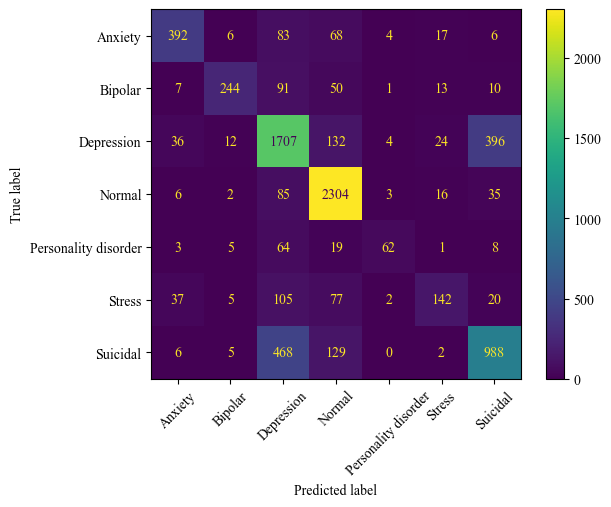

In [22]:
cm_v3 = confusion_matrix(y_val, y_val_pred_v3)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_v3,
    xticks_rotation=45)

### Eksperyment 1.4
- usunięcie stopwords 
- tylko alfanumeryczne tokeny
- lematyzacja uwzględniająca części mowy

In [23]:
X_train_v4 = X_train.apply(preprocess_v4)
X_val_v4 = X_val.apply(preprocess_v4)
X_test_v4 = X_test.apply(preprocess_v4)

In [24]:
baseline.fit(X_train_v4, y_train)
y_val_pred_v4 = baseline.predict(X_val_v4)
f1_macro_v4 = f1_score(y_val, y_val_pred_v4, average='macro')

print(classification_report(y_val, y_val_pred_v4))
print(f"F1 macro: {f1_macro_v4:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.80      0.68      0.73       576
             Bipolar       0.89      0.58      0.70       416
          Depression       0.65      0.73      0.69      2311
              Normal       0.83      0.94      0.88      2451
Personality disorder       0.86      0.38      0.53       162
              Stress       0.70      0.36      0.48       388
            Suicidal       0.66      0.62      0.64      1598

            accuracy                           0.74      7902
           macro avg       0.77      0.61      0.67      7902
        weighted avg       0.74      0.74      0.73      7902

F1 macro: 0.67


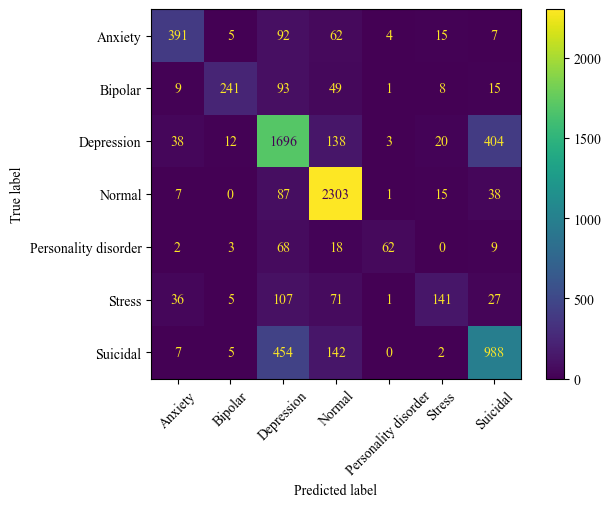

In [25]:
cm_v4 = confusion_matrix(y_val, y_val_pred_v4)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_v4,
    xticks_rotation=45)

### Eksperyment 1.5
Zależność otrzymywanego `f1_score` od wartości parametry `max_features` w `TfidfVectorizer`.

In [63]:
X_train_base = X_train.apply(preprocess)
X_val_base = X_val.apply(preprocess)
X_test_base = X_test.apply(preprocess)

In [28]:
print("Baseline:")
matrixes_base, f1_scores_base = max_features(X_train_base, X_val_base, y_train, y_val)

Baseline:
max_features=500, F1 macro: 0.62
max_features=1000, F1 macro: 0.66
max_features=1500, F1 macro: 0.68
max_features=2000, F1 macro: 0.69
max_features=2500, F1 macro: 0.70
max_features=3000, F1 macro: 0.70
max_features=3500, F1 macro: 0.70
max_features=4000, F1 macro: 0.70
max_features=4500, F1 macro: 0.70
max_features=5000, F1 macro: 0.70
max_features=None, F1 macro: 0.70


In [29]:
print("\nPreprocessing v1:")
matrixes_v1, f1_scores_v1 = max_features(X_train_v1, X_val_v1, y_train, y_val)


Preprocessing v1:
max_features=500, F1 macro: 0.59
max_features=1000, F1 macro: 0.64
max_features=1500, F1 macro: 0.66
max_features=2000, F1 macro: 0.66
max_features=2500, F1 macro: 0.66
max_features=3000, F1 macro: 0.67
max_features=3500, F1 macro: 0.67
max_features=4000, F1 macro: 0.67
max_features=4500, F1 macro: 0.67
max_features=5000, F1 macro: 0.67
max_features=None, F1 macro: 0.67


In [30]:
print("\nPreprocessing v2:")
matrixes_v2, f1_scores_v2 = max_features(X_train_v2, X_val_v2, y_train, y_val)


Preprocessing v2:
max_features=500, F1 macro: 0.59
max_features=1000, F1 macro: 0.64
max_features=1500, F1 macro: 0.65
max_features=2000, F1 macro: 0.66
max_features=2500, F1 macro: 0.66
max_features=3000, F1 macro: 0.66
max_features=3500, F1 macro: 0.67
max_features=4000, F1 macro: 0.66
max_features=4500, F1 macro: 0.66
max_features=5000, F1 macro: 0.66
max_features=None, F1 macro: 0.66


In [31]:
print("\nPreprocessing v3:")
matrixes_v3, f1_scores_v3 = max_features(X_train_v3, X_val_v3, y_train, y_val)


Preprocessing v3:
max_features=500, F1 macro: 0.60
max_features=1000, F1 macro: 0.66
max_features=1500, F1 macro: 0.66
max_features=2000, F1 macro: 0.66
max_features=2500, F1 macro: 0.67
max_features=3000, F1 macro: 0.67
max_features=3500, F1 macro: 0.67
max_features=4000, F1 macro: 0.67
max_features=4500, F1 macro: 0.67
max_features=5000, F1 macro: 0.67
max_features=None, F1 macro: 0.66


In [32]:
print("\nPreprocessing v4:")
matrixes_v4, f1_scores_v4 = max_features(X_train_v4, X_val_v4, y_train, y_val)


Preprocessing v4:
max_features=500, F1 macro: 0.59
max_features=1000, F1 macro: 0.65
max_features=1500, F1 macro: 0.65
max_features=2000, F1 macro: 0.66
max_features=2500, F1 macro: 0.66
max_features=3000, F1 macro: 0.67
max_features=3500, F1 macro: 0.67
max_features=4000, F1 macro: 0.67
max_features=4500, F1 macro: 0.66
max_features=5000, F1 macro: 0.66
max_features=None, F1 macro: 0.67


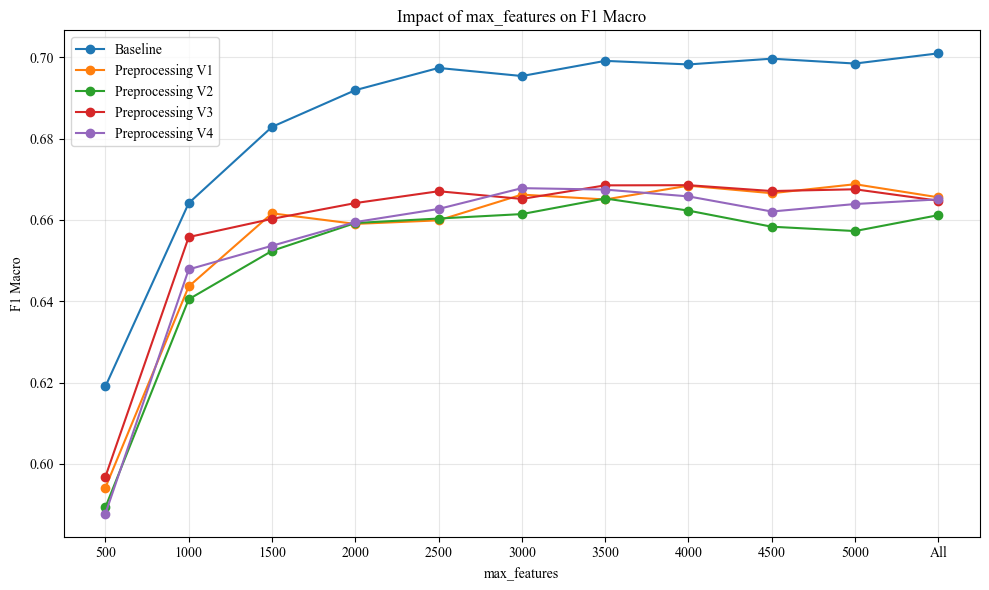

In [33]:
# wizualizacja wpływu max_features na F1 macro
x_base, y_base = prepare_plot_data(f1_scores_base)
x_v1, y_v1 = prepare_plot_data(f1_scores_v1)
x_v2, y_v2 = prepare_plot_data(f1_scores_v2)
x_v3, y_v3 = prepare_plot_data(f1_scores_v3)
x_v4, y_v4 = prepare_plot_data(f1_scores_v4)

plt.figure(figsize=(10, 6))
plt.plot(x_base, y_base, marker='o', label='Baseline')
plt.plot(x_v1, y_v1, marker='o', label='Preprocessing V1')
plt.plot(x_v2, y_v2, marker='o', label='Preprocessing V2')
plt.plot(x_v3, y_v3, marker='o', label='Preprocessing V3')
plt.plot(x_v4, y_v4, marker='o', label='Preprocessing V4')

plt.title("Impact of max_features on F1 Macro")
plt.xlabel("max_features")
plt.ylabel("F1 Macro")

plt.xticks(
    [500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500],
    ['500','1000','1500','2000','2500','3000','3500','4000','4500','5000','All']
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### ...

In [34]:
baseline.fit(X_train_base, y_train)
y_val_pred = baseline.predict(X_val_base)

In [37]:
predictions = {
    "baseline" : y_val_pred,
    "v1" : y_val_pred_v1,
    "v2" : y_val_pred_v2,
    "v3" : y_val_pred_v3,
    "v4" : y_val_pred_v4,
}

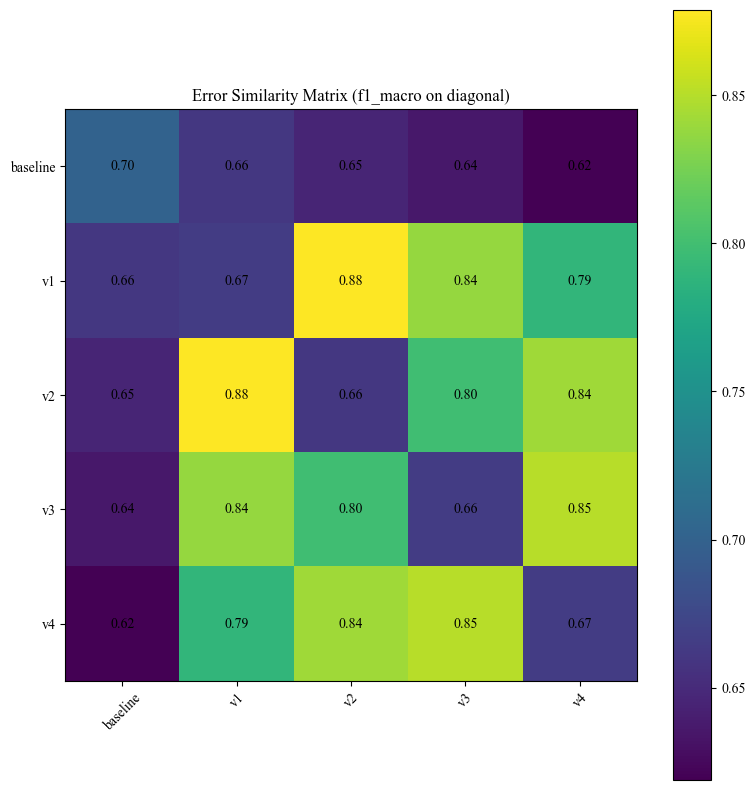

In [58]:
results, metrics = compare_errors(predictions, y_val)
plot_error_matrix(results, metrics, metric='f1_macro')

In [59]:
print_error_examples(
    results,
    X_val_base,
    y_val,
    predictions,
    n_examples=3
)


baseline vs v1

--- Shared errors ---

ID: 3
TEXT: sense of fear have you ever felt a sense of fear that seemed to take over your body and mind, leaving you feeling helpless? fear can be a paralyzing emotion, preventing us from moving forward in life. but what if there was something you could do about it? what if there were ways to get rid of the se
TRUE: Stress
baseline: Anxiety
v1: Anxiety

ID: 8
TEXT: can’t take it anymore today has been one of the worst days in a long time. out of so many countless times i have wanted to just give up and end it, i kept going. thought i was getting a loan so i could get out of debt and actually have some money to get things i desperately need since i haven’t work
TRUE: Bipolar
baseline: Depression
v1: Depression

ID: 11
TEXT: i always make mistakes, and bad decisions. i have no skills or talents. i have no accomplishments. i feel like a useless person. my parents make me feel stupid, for every mistake that i make. i feel like i will never be where 

In [60]:
analysis = analyze_common_cases(
    predictions,
    y_val,
    X_val_base,
    k_examples=3
)

ALL MODELS CORRECT

Count: 5280

Class distribution:
Normal                  2229
Depression              1495
Suicidal                 847
Anxiety                  346
Bipolar                  205
Stress                   103
Personality disorder      55
dtype: int64

Examples:

----------------------------------------
ID: 0
TRUE: Normal
TEXT:
@marthastewart proof?

----------------------------------------
ID: 1
TRUE: Depression
TEXT:
when i get told i am a good guy it sometimes drives me near to tears. i have been told how nice i am. how funny i am. how dependable. i have been told many times by different people these things so it must be true right? but i guess i am not good enough. if i was it would not be so hard to find and keep people in my life. i know it sounds self serving and all pity party but its how i feel and the thoughts in my head. i realize and understand that i am not a priority to anyone else. i just wish i

----------------------------------------
ID: 2
TRUE: Norma